# CDC API exploration

Probe the CDC MCP tools. The MCP server must be running (`python mcp_server/server.py`).

CDC data lives on a Socrata portal (`data.cdc.gov`); reading needs no credentials
(an optional `CDC_API_KEY` app token only raises rate limits). Each dataset has
its own schema, so **discover** a dataset, **inspect its columns**, then **query** it.

In [11]:
%reload_ext autoreload
%autoreload 2

import sys
from matplotlib import pyplot
from lib import config

sys.path.append('../')

from utils import (
    call_tool,
    list_mcp_tools,
    discover,
    show_columns,
    get_rows,
    plot_cdc_series,
    plot_cdc_series_by,
)

pyplot.style.use(config.glyfish_style)

## Available tools

In [21]:
await list_mcp_tools()

fred_category_children: List the child categories for a FRED category.
fred_category_series: List the series contained within a FRED category.
fred_series_info: Fetch metadata for a single FRED series.
fred_series_observations: Return observations for a series (limit defaults to 100).
fred_series_updates: Return recently updated FRED series.
list_releases: List the series that belong to a FRED release.
fred_release_series: List the series that belong to a FRED release.
tiingo_series_info: Fetch metadata for a Tiingo ticker (ETF, mutual fund, or stock), including its available date range.
tiingo_price_series: Return the end-of-day price series (OHLCV plus split/dividend-adjusted prices) for a Tiingo ticker. Provide start_date/end_date as YYYY-MM-DD for a range; omit for the latest day.
bls_series_data: Fetch observations for one or more BLS series IDs (up to 50). Optionally restrict to a start_year/end_year range and enable catalog metadata, net/percent-change calculations, annual avera

## Discover datasets

Search the CDC catalog for the SDT health metrics — life expectancy and the
"deaths of despair" components (drug overdose, suicide).

In [31]:
# await discover("life expectancy")
# await discover("drug overdose deaths")
# await discover("suicide")
await discover("alcohol")


haed-k2ka      Occupant and Alcohol-Impaired Driving Deaths in States, 2005-2014
grbx-2j68      Graph of Alcohol Use 3 Months Before and Last 3 Months of Pregnancy
hfr9-rurv      Alzheimer's Disease and Healthy Aging Data
hksd-2xuw      U.S. Chronic Disease Indicators
xs7u-t3bn      Alzheimer's Disease and Healthy Aging Indicators: Caregiving
jhd5-u276      Alzheimer's Disease and Healthy Aging Indicators: Cognitive Decline
mtgp-t7vw      DQS Use of selected substances in the past 30 days among 12th graders, 10th graders, and 8th graders, by sex and race: United States.
mbvg-apdj      Graph of Tobacco Use 3 Months Before and Last 3 Months of Pregnancy
qwpv-wpc8      CDC PRAMStat Data for 2009
dnxe-zgxs      CDC PRAMStat Data for 2002


[{'id': 'haed-k2ka',
  'name': 'Occupant and Alcohol-Impaired Driving Deaths in States, 2005-2014',
  'description': "Alcohol-Impaired Driving Fatalities 2005-2014; All persons killed in crashes involving a driver with BAC >= .08 g/dL. Occupant Fatalities 2005-2014; All occupants killed where body type = 1-79. Source: National Highway Traffic Safety Administration's (NHTSA) Fatality Analysis Reporting System (FARS), 2005-2013 Final Reports and 2014 Annual Report File",
  'domain': 'data.cdc.gov'},
 {'id': 'grbx-2j68',
  'name': 'Graph of Alcohol Use 3 Months Before and Last 3 Months of Pregnancy',
  'description': '2011.  Centers for Disease Control and Prevention (CDC).  PRAMS, the Pregnancy Risk Assessment Monitoring System, is a surveillance system collecting state-specific, population-based data on maternal attitudes and experiences before, during, and shortly after pregnancy. It is a collaborative project of the Centers for Disease Control and Prevention (CDC) and state health dep

## Inspect a dataset's columns

Schemas differ per dataset, so check the columns to find the time / value / facet
fields. `w9j2-ggv5` is death rates & life expectancy (1900→), keyed by year × race × sex.

In [14]:
await show_columns("w9j2-ggv5")

w9j2-ggv5: NCHS - Death rates and life expectancy at birth
  year                             number   Year
  race                             text     Race
  sex                              text     Sex
  average_life_expectancy          number   Average Life Expectancy (Years)
  mortality                        number   Age-adjusted Death Rate


[{'field_name': 'year',
  'name': 'Year',
  'data_type': 'number',
  'description': None},
 {'field_name': 'race',
  'name': 'Race',
  'data_type': 'text',
  'description': None},
 {'field_name': 'sex',
  'name': 'Sex',
  'data_type': 'text',
  'description': None},
 {'field_name': 'average_life_expectancy',
  'name': 'Average Life Expectancy (Years)',
  'data_type': 'number',
  'description': None},
 {'field_name': 'mortality',
  'name': 'Age-adjusted Death Rate',
  'data_type': 'number',
  'description': None}]

## Query a series

Life expectancy for all races / both sexes over the full record. `where` is a
SoQL predicate; Socrata returns values as strings.

In [15]:
rows = await get_rows(
    "w9j2-ggv5",
    where="race='All Races' AND sex='Both Sexes'",
    order="year",
)
print(len(rows), "rows")
rows[0]

119 rows


{'year': '1900',
 'race': 'All Races',
 'sex': 'Both Sexes',
 'average_life_expectancy': '47.3',
 'mortality': '2518.0'}

## Plot

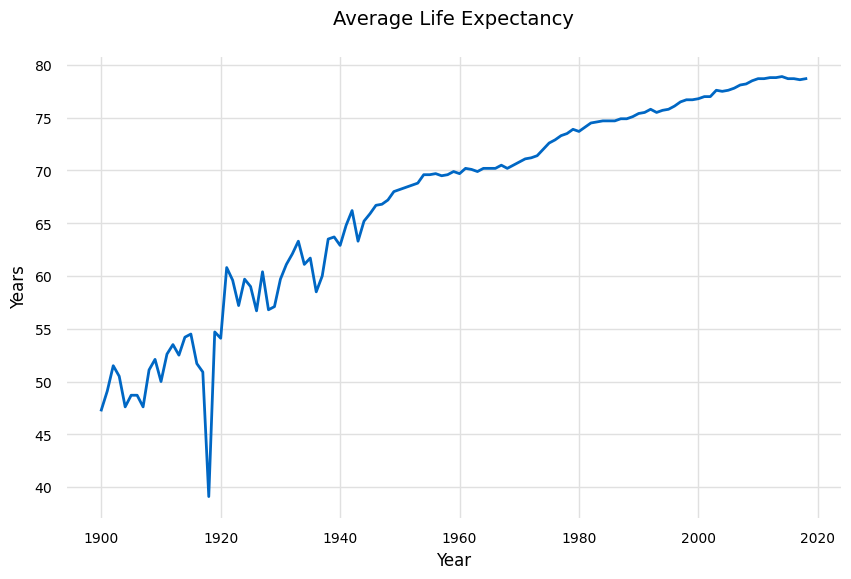

In [16]:
plot_cdc_series(rows, "year", "average_life_expectancy", ylabel="Years")

## Life expectancy by sex and by race

The plot above is the aggregate — `All Races` / `Both Sexes`. Break it out one
facet at a time, holding the other facet at its aggregate, and overlay the groups
on a single shared scale with `plot_cdc_series_by`. The helper drops the
facet-wide total (`Both Sexes`, `All Races`) so the breakdown stays readable, and
reuses `cdc_rows_to_arrays` to skip the suppressed 2018 `Black`/`White`
life-expectancy cells — so those lines end at 2017 while `All Races` runs to 2018.

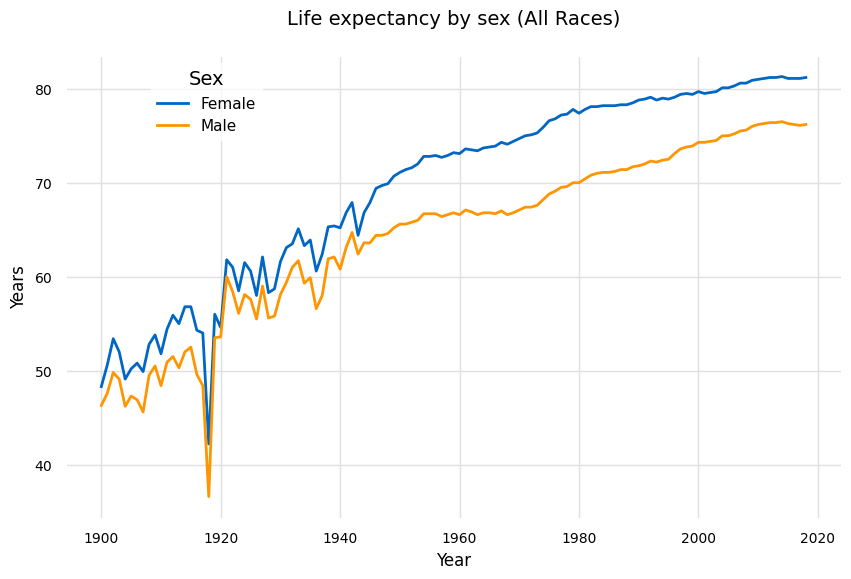

In [17]:
# By sex, holding race constant at the 'All Races' aggregate.
by_sex = await get_rows(
    "w9j2-ggv5",
    where="race='All Races'",
    order="sex, year",
)
plot_cdc_series_by(
    by_sex, "year", "average_life_expectancy", "sex",
    title="Life expectancy by sex (All Races)", ylabel="Years",
)

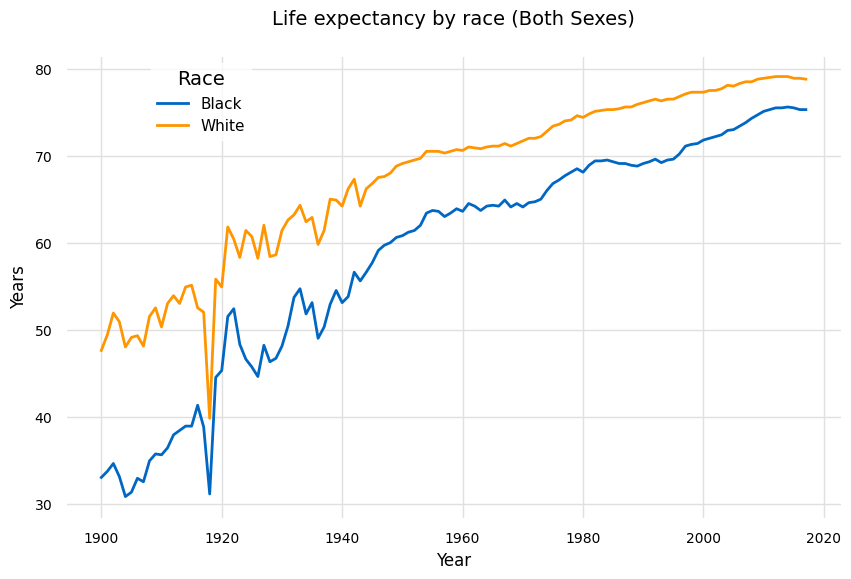

In [18]:
# By race, holding sex constant at the 'Both Sexes' aggregate.
by_race = await get_rows(
    "w9j2-ggv5",
    where="sex='Both Sexes'",
    order="race, year",
)
plot_cdc_series_by(
    by_race, "year", "average_life_expectancy", "race",
    title="Life expectancy by race (Both Sexes)", ylabel="Years",
)

### Keep the overall aggregate for reference

Pass `exclude=()` to keep the facet-wide total in the overlay. Here the
`Both Sexes` average is labeled alongside the `Female` and `Male` lines as the
overall reference baseline.

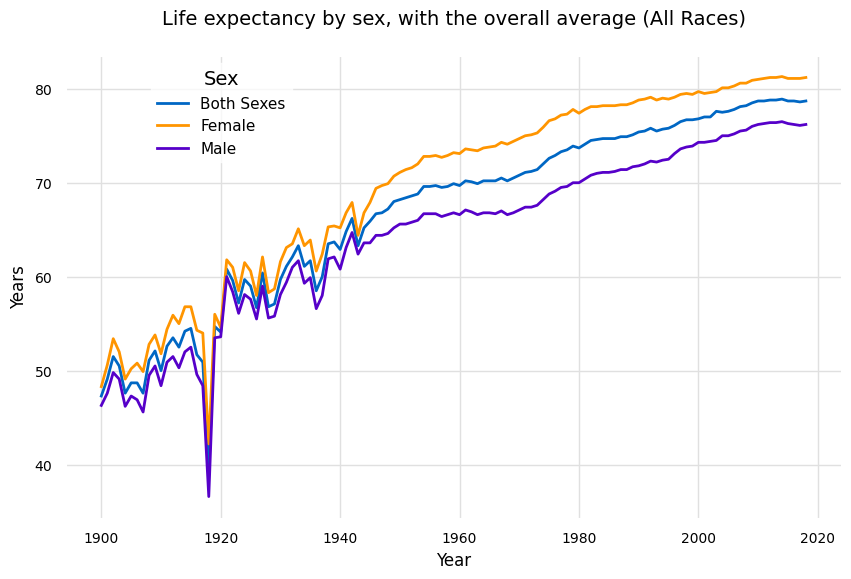

In [19]:
# exclude=() keeps 'Both Sexes' so the overall average is labeled for reference.
plot_cdc_series_by(
    by_sex, "year", "average_life_expectancy", "sex", exclude=(),
    title="Life expectancy by sex, with the overall average (All Races)",
    ylabel="Years",
)

## Deaths-of-despair components

Suicide death rates (`9j2v-jamp`, NCHS stub schema) — all persons, all ages.
Overdose counts (`xkb8-kh2a`) are monthly/provisional by state and drug type, so
they need a different time field (`year` + `month`) and value (`data_value`).

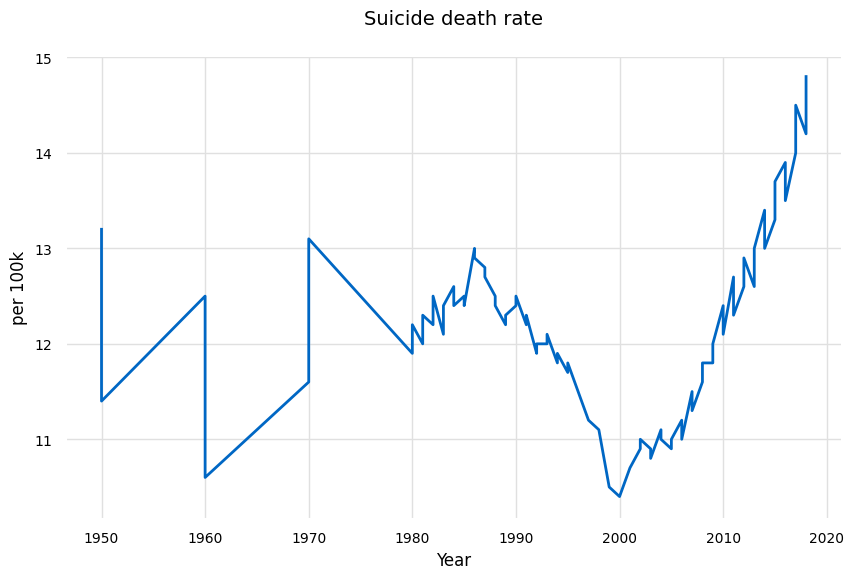

In [20]:
suicide = await get_rows(
    "9j2v-jamp",
    where="stub_label='All persons' AND age='All ages'",
    order="year",
)
plot_cdc_series(suicide, "year", "estimate", title="Suicide death rate", ylabel="per 100k")